# 한국 증시자금·레버리지 지표

공공데이터포털에서 3개 API를 받아 빚투 위험도 지표를 계산합니다.

| # | API | 오퍼레이션 | 용도 |
|---|---|---|---|
| 1 | 금융투자협회종합통계정보 | `getGrantingOfCreditBalanceInfo` | 신용공여잔고추이 |
| 2 | 금융투자협회종합통계정보 | `getSecuritiesMarketTotalCapitalInfo` | 증시자금추이 |
| 3 | **지수시세정보** | `getStockMarketIndex` | 시가총액·거래대금 (분모용) |

3번은 **별도 활용신청**이 필요합니다. 아직 승인 전이면 해당 셀만 건너뛰고
시총이 필요 없는 지표만 계산됩니다 (`HAS_INDEX = False` 로 자동 분기).

저장 위치: `<OneDrive>/INVESTMENT/지표상회_복제/한국_증시자금동향/증시자금동향_{날짜}.xlsx`

## 0. 패키지 설치 (최초 1회만)

In [ ]:
# PyCharm 터미널에서 실행해도 됩니다.
# !pip install requests pandas openpyxl matplotlib
import sys
print(sys.version)

## 1. 설정

### serviceKey 주의사항
- `requests`의 `params=` 로 넘길 때는 **Decoding 키**를 씁니다.
- Encoding 키를 `params=` 로 넘기면 `%`가 `%25`로 이중 인코딩되어 코드 30 에러가 납니다.
- 인증 에러가 계속 나면 `USE_ENCODED_KEY = True` + Encoding 키로 바꿔 보세요.

### 단위 주의사항 (중요)
세 API의 금액 단위가 **서로 다릅니다.**

| 데이터 | 샘플값 | 실제 | 단위 |
|---|---|---|---|
| `crdTrFingWhl` (신용융자) | 17,461,184 | 17.46조원 | **백만원** |
| `invrDpsgAmt` (투자자예탁금) | 52,567,764,085,909 | 52.57조원 | **원** |
| `lstgMrktTotAmt` (시가총액) | 확인 필요 | — | 원으로 추정 |

아래 `UNIT_DIVISOR` 에서 **조원 기준으로 통일**합니다.
지수 API 단위는 실제 코스피 시총(2천조원 내외)과 대조해 확인 후 조정하세요.

In [1]:
# -*- coding: utf-8 -*-
import os

# ============================================================
# 사용자 설정
# ============================================================

# [기본] Decoding 키
SERVICE_KEY = "2o6NG3ixxDgGQ9S4dWUgsMac9WlxfX46+JvFRsAlsXQ6xVi6CZewvNJvbHd4S7exkWwt3YWoKSdwvUNb46kSTQ=="

# [대안] 인증 에러가 계속 나면 True 로 바꾸고 위 SERVICE_KEY 를 Encoding 키로 교체
USE_ENCODED_KEY = False

# 조회 기간 (YYYYMMDD). 두 번의 사이클을 담으려면 2015년 이후 권장
BEGIN_DT = "20150101"
END_DT   = None           # None 이면 오늘까지

NUM_OF_ROWS = 1000        # 한 번에 받아올 행 수 (1~1000)
SLEEP_SEC = 0.2           # 요청 간 대기(초). API 제한 30 TPS

# ------------------------------------------------------------
# 지수시세정보 (시가총액·거래대금)
# ------------------------------------------------------------
# 별도 활용신청 필요. 아직이면 FETCH_INDEX = False 로 두세요.
FETCH_INDEX = True

# 대상 시장. 코스피만 볼지, 코스닥까지 합칠지.
#   ("코스피",)            → 코스피 단독
#   ("코스피", "코스닥")   → 두 시장 합산
INDEX_KEYWORDS = ("코스피",)

# 지수명을 직접 지정하고 싶을 때만 사용 (None 이면 자동 탐색)
#   자동 탐색은 키워드가 들어간 지수 중 '채용 종목수가 가장 많은' 것을 종합지수로 봅니다.
INDEX_NAMES_OVERRIDE = None

# ------------------------------------------------------------
# 단위 정규화 : 모든 금액을 '조원' 으로 통일
# ------------------------------------------------------------
# API 가 원/백만원 중 무엇으로 응답하는지 문서와 실제가 다른 경우가 있어
# 실측값이 상식적 범위에 들어가는 나눗수를 자동으로 고릅니다.
AUTO_UNIT = True

# 자동 탐지 실패 시 쓰이는 수동 나눗수 (조원 기준)
UNIT_DIVISOR = {
    "credit": 1e12,   # 신용공여 : 실제 응답은 '원' 이었음 (가이드 문서의 백만원 표기와 다름)
    "market": 1e12,   # 증시자금 : 원
    "index":  1e12,   # 지수시세 : 원
}

# 자동 탐지에 쓰는 '상식적 범위' (조원)
PLAUSIBLE = {
    "credit":   (3, 200),      # 신용거래융자
    "market":   (10, 500),     # 투자자예탁금
    "mktcap":   (300, 10000),  # 시가총액
    "turnover": (0.5, 200),    # 일 거래대금
}

# 반대매매 지표는 2024년 전후로 산출 기준이 바뀐 흔적이 있어
# 백분위/z-score 를 이 날짜 이후 구간으로만 계산합니다.
STRESS_SINCE = "2024-01-01"

# ------------------------------------------------------------
# 지표 계산 파라미터
# ------------------------------------------------------------
MA_SHORT = 20      # 거래대금 이동평균 / 예탁금 평활 (영업일)
MOM_WIN  = 60      # 모멘텀·4분면 기간 (영업일, 약 3개월)
Z_WIN    = 750     # z-score 기간 (약 3년)
PCT_WIN  = 1250    # 백분위 기간 (약 5년)

# ------------------------------------------------------------
# 저장 설정   ※ 실제 경로는 다음 셀에서 자동 탐색
# ------------------------------------------------------------
OUT_DIR_OVERRIDE = None
# 예) OUT_DIR_OVERRIDE = r"C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\한국_증시자금동향"

ONEDRIVE_SUBPATH = ("INVESTMENT", "지표상회_복제", "한국_증시자금동향")
TARGET_FOLDER_NAME = "한국_증시자금동향"

FILE_PREFIX = "증시자금동향"
DATE_TAG_MODE = "lastdata"    # "lastdata" = 데이터 최종일, "today" = 실행일
OVERWRITE = True
SAVE_CSV_TOO = True

# ============================================================
BASE_URL       = "https://apis.data.go.kr/1160100/service/GetKofiaStatisticsInfoService"
INDEX_BASE_URL = "https://apis.data.go.kr/1160100/service/GetMarketIndexInfoService"

OP_CREDIT = "getGrantingOfCreditBalanceInfo"          # 신용공여잔고추이
OP_MARKET = "getSecuritiesMarketTotalCapitalInfo"     # 증시자금추이
OP_INDEX  = "getStockMarketIndex"                     # 지수시세

print("설정 완료")

설정 완료


## 2. 저장 경로 자동 탐색

데스크탑과 노트북의 경로가 달라도 알아서 찾습니다. 시도 순서는 이렇습니다.

1. `OUT_DIR_OVERRIDE` 가 지정돼 있으면 그것을 사용
2. 환경변수 `OneDrive` / `OneDriveConsumer` / `OneDriveCommercial` + 상대경로
3. 홈 디렉터리 아래 `OneDrive*` 폴더 (예: `OneDrive - 회사명`) + 상대경로
4. 위 후보의 **상위 폴더**가 존재하면 최종 폴더를 새로 생성
5. 그래도 없으면 OneDrive 루트를 훑어 `한국_증시자금동향` 을 **폴더명으로 검색**
6. 전부 실패하면 노트북 옆 `./data` 로 폴백

In [2]:
# -*- coding: utf-8 -*-
import os
import glob


def _dedup(seq):
    seen, out = set(), []
    for x in seq:
        if x and x not in seen:
            seen.add(x)
            out.append(x)
    return out


def find_onedrive_roots():
    """이 PC 에서 쓸 수 있는 OneDrive 루트 후보를 모두 수집"""
    roots = []

    # (a) Windows 가 설정해 주는 환경변수
    for var in ("OneDrive", "OneDriveConsumer", "OneDriveCommercial"):
        roots.append(os.environ.get(var))

    # (b) 홈 디렉터리 아래의 OneDrive 계열 폴더 (OneDrive - 회사명 포함)
    home = os.path.expanduser("~")
    for pat in ("OneDrive", "OneDrive*", "OneDrive - *"):
        for hit in glob.glob(os.path.join(home, pat)):
            if os.path.isdir(hit):
                roots.append(hit)

    # (c) 다른 드라이브에 있는 경우 (D:\OneDrive 등)
    for drive in ("C:", "D:", "E:"):
        cand = os.path.join(drive + os.sep, "OneDrive")
        if os.path.isdir(cand):
            roots.append(cand)

    roots = [os.path.normpath(r) for r in roots if r and os.path.isdir(r)]
    return _dedup(roots)


def search_folder_by_name(roots, name, max_depth=5):
    """OneDrive 루트 아래에서 폴더명을 깊이 제한으로 탐색"""
    for root in roots:
        base_depth = root.rstrip(os.sep).count(os.sep)
        for dirpath, dirnames, _ in os.walk(root):
            if dirpath.count(os.sep) - base_depth >= max_depth:
                dirnames[:] = []
                continue
            dirnames[:] = [d for d in dirnames
                           if not d.startswith(".") and not d.startswith("~$")]
            if name in dirnames:
                return os.path.join(dirpath, name)
    return None


def resolve_out_dir(verbose=True):
    sub = os.path.join(*ONEDRIVE_SUBPATH)

    if OUT_DIR_OVERRIDE:
        path = os.path.normpath(os.path.expanduser(OUT_DIR_OVERRIDE))
        os.makedirs(path, exist_ok=True)
        if verbose:
            print("[1] OUT_DIR_OVERRIDE 사용")
        return path

    roots = find_onedrive_roots()
    if verbose:
        print("탐지된 OneDrive 루트:")
        for r in roots:
            print("   -", r)
        if not roots:
            print("   (없음)")
        print()

    candidates = [os.path.join(r, sub) for r in roots]

    for c in candidates:
        if os.path.isdir(c):
            if verbose:
                print("[2] 기존 폴더 발견")
            return c

    for c in candidates:
        if os.path.isdir(os.path.dirname(c)):
            os.makedirs(c, exist_ok=True)
            if verbose:
                print("[4] 상위 폴더 확인 후 최종 폴더 생성")
            return c

    if roots:
        if verbose:
            print("[5] 폴더명으로 검색 중... (수 초 걸릴 수 있음)")
        found = search_folder_by_name(roots, TARGET_FOLDER_NAME)
        if found:
            if verbose:
                print("[5] 이름 검색으로 발견")
            return found

    fallback = os.path.abspath("./data")
    os.makedirs(fallback, exist_ok=True)
    if verbose:
        print("[6] !! OneDrive 경로를 찾지 못해 로컬 폴더로 폴백합니다.")
        print("     OUT_DIR_OVERRIDE 에 경로를 직접 넣어주세요.")
    return fallback


OUT_DIR = resolve_out_dir()

print()
print("최종 저장 경로 :", OUT_DIR)
print("쓰기 가능 여부 :", os.access(OUT_DIR, os.W_OK))

탐지된 OneDrive 루트:
   - C:\Users\82108\OneDrive

[2] 기존 폴더 발견

최종 저장 경로 : C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\한국_증시자금동향
쓰기 가능 여부 : True


## 3. 공통 유틸

- `call_api()` : 단일 페이지 호출. `base_url` 인자로 서비스를 바꿀 수 있습니다
- 응답이 JSON이 아닌 XML로 올 수 있어서(에러 시 항상 XML) 두 경우 모두 파싱
- 에러 코드는 가이드 문서 2장 기준으로 한글 메시지 매핑

In [3]:
# -*- coding: utf-8 -*-
import time
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta

import requests
import numpy as np
import pandas as pd


ERROR_MSG = {
    "1":  "APPLICATION_ERROR - 어플리케이션 에러",
    "4":  "HTTP_ERROR",
    "12": "NO_OPENAPI_SERVICE_ERROR - 해당 오픈API서비스가 없거나 폐기됨",
    "20": "SERVICE_ACCESS_DENIED_ERROR - 서비스 접근 거부 (활용신청 확인)",
    "22": "LIMITED_NUMBER_OF_SERVICE_REQUESTS_EXCEEDS_ERROR - 일 트래픽 초과",
    "30": "SERVICE_KEY_IS_NOT_REGISTERED_ERROR - 등록되지 않은 인증키",
    "31": "DEADLINE_HAS_EXPIRED_ERROR - 활용기간 만료",
    "32": "UNREGISTERED_IP_ERROR - 등록되지 않은 IP",
    "99": "UNKNOWN_ERROR - 기타 에러",
}


class OpenApiError(Exception):
    pass


def _parse_xml(text):
    root = ET.fromstring(text)

    # 인증/트래픽 에러는 <OpenAPI_ServiceResponse> 형태로 옴
    if root.tag.endswith("OpenAPI_ServiceResponse"):
        code = root.findtext(".//returnReasonCode") or ""
        msg = root.findtext(".//returnAuthMsg") or root.findtext(".//errMsg") or ""
        raise OpenApiError("[{}] {} / {}".format(code, msg, ERROR_MSG.get(code, "")))

    header = {
        "resultCode": root.findtext(".//resultCode") or "",
        "resultMsg": root.findtext(".//resultMsg") or "",
    }
    body = {
        "numOfRows": int(root.findtext(".//body/numOfRows") or 0),
        "pageNo": int(root.findtext(".//body/pageNo") or 0),
        "totalCount": int(root.findtext(".//body/totalCount") or 0),
        "items": [],
    }
    for item in root.findall(".//items/item"):
        row = {}
        for child in item:
            row[child.tag] = (child.text or "").strip()
        body["items"].append(row)
    return header, body


def _parse_json(payload):
    resp = payload.get("response", payload)
    header = resp.get("header", {}) or {}
    raw_body = resp.get("body", {}) or {}

    items = raw_body.get("items", {})
    if isinstance(items, dict):
        item = items.get("item", [])
    elif isinstance(items, list):
        item = items
    else:
        item = []
    if isinstance(item, dict):
        item = [item]

    body = {
        "numOfRows": int(raw_body.get("numOfRows") or 0),
        "pageNo": int(raw_body.get("pageNo") or 0),
        "totalCount": int(raw_body.get("totalCount") or 0),
        "items": item,
    }
    return header, body


def call_api(operation, page_no=1, num_of_rows=10, extra=None,
             base_url=None, timeout=30, verbose=False):
    """오픈API 단일 페이지 호출. base_url 로 서비스 전환 가능"""
    url = "{}/{}".format(base_url or BASE_URL, operation)

    params = {
        "pageNo": page_no,
        "numOfRows": num_of_rows,
        "resultType": "json",
    }
    if extra:
        for k, v in extra.items():
            if v is not None and v != "":
                params[k] = v

    if USE_ENCODED_KEY:
        # 이미 인코딩된 키는 requests 가 재인코딩하지 않도록 URL 에 직접 붙임
        qs = "&".join("{}={}".format(k, v) for k, v in params.items())
        r = requests.get("{}?serviceKey={}&{}".format(url, SERVICE_KEY, qs),
                         timeout=timeout)
    else:
        params["serviceKey"] = SERVICE_KEY
        r = requests.get(url, params=params, timeout=timeout)

    if verbose:
        print("GET", r.url[:300])

    r.raise_for_status()
    text = r.text.strip()

    if text.startswith("<"):
        header, body = _parse_xml(text)
    else:
        try:
            header, body = _parse_json(r.json())
        except ValueError:
            raise OpenApiError("응답 파싱 실패. 원문 앞부분:\n" + text[:500])

    code = str(header.get("resultCode", "")).lstrip("0") or "0"
    if code == "3":          # NODATA_ERROR
        body["items"] = []
        body["totalCount"] = 0
        return header, body
    if code != "0":
        raise OpenApiError("[{}] {} / {}".format(
            header.get("resultCode"), header.get("resultMsg"),
            ERROR_MSG.get(code, "")))

    return header, body


def fetch_all(operation, extra=None, num_of_rows=1000, base_url=None,
              max_pages=500, verbose=True, label=None):
    """전체 페이지를 순회하며 DataFrame 으로 반환"""
    rows = []
    page = 1
    total = None
    tag = label or operation

    while page <= max_pages:
        header, body = call_api(operation, page_no=page, num_of_rows=num_of_rows,
                                extra=extra, base_url=base_url)
        if total is None:
            total = body["totalCount"]
            if verbose:
                print("[{}] totalCount = {:,}".format(tag, total))

        items = body["items"]
        if not items:
            break
        rows.extend(items)

        if verbose:
            print("  page {:>3} : +{:>5} rows (누적 {:,}/{:,})".format(
                page, len(items), len(rows), total))

        if len(rows) >= total:
            break
        page += 1
        time.sleep(SLEEP_SEC)

    return pd.DataFrame(rows)


def to_numeric(df, cols):
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(
                out[c].astype(str).str.replace(",", "", regex=False).str.strip(),
                errors="coerce")
    return out


def build_date_filter(begin_dt, end_dt):
    """basDt 범위. endBasDt 는 '검색값보다 작은' = 미포함이라 +1일 보정"""
    f = {}
    if begin_dt:
        f["beginBasDt"] = begin_dt
    if end_dt:
        d = datetime.strptime(end_dt, "%Y%m%d") + timedelta(days=1)
        f["endBasDt"] = d.strftime("%Y%m%d")
    return f


UNIT_LABEL = {1.0: "조원", 1e4: "억원", 1e6: "백만원", 1e8: "만원",
              1e9: "천원", 1e12: "원"}


def auto_unit_divisor(sample, lo, hi, name="", fallback=1e12, verbose=True):
    """sample(원본 숫자)을 [lo, hi] 조원 범위에 넣는 나눗수를 찾는다."""
    if sample is None or not np.isfinite(sample) or sample <= 0:
        return fallback
    for div in (1.0, 1e4, 1e6, 1e8, 1e9, 1e12):
        if lo <= sample / div <= hi:
            if verbose:
                print("   {:<10} 원본 {:>22,.0f} → {:>8.2f}조  (단위: {})".format(
                    name, sample, sample / div, UNIT_LABEL[div]))
            return div
    if verbose:
        print("   {:<10} !! 자동 탐지 실패. 원본 {:,.0f} → 수동값 사용".format(name, sample))
    return fallback


print("유틸 로드 완료")

유틸 로드 완료


## 4. 연결 테스트 (디버깅용)

1건씩만 받아서 인증키/오퍼레이션명이 정상인지 확인합니다.

In [4]:
try:
    header, body = call_api(OP_CREDIT, page_no=1, num_of_rows=1, verbose=True)
    print("\nheader :", header)
    print("total  :", body["totalCount"])
    for k, v in (body["items"][0] if body["items"] else {}).items():
        print("   {:<28} {}".format(k, v))
except Exception as e:
    print("!! 실패:", type(e).__name__, e)

GET https://apis.data.go.kr/1160100/service/GetKofiaStatisticsInfoService/getGrantingOfCreditBalanceInfo?pageNo=1&numOfRows=1&resultType=json&serviceKey=2o6NG3ixxDgGQ9S4dWUgsMac9WlxfX46%2BJvFRsAlsXQ6xVi6CZewvNJvbHd4S7exkWwt3YWoKSdwvUNb46kSTQ%3D%3D

header : {'resultCode': '00', 'resultMsg': 'NORMAL SERVICE.'}
total  : 1151
   basDt                        20260727
   crdTrFingWhl                 32741062787550
   crdTrFingScrs                25835505537512
   crdTrFingKosdaq              6905557250038
   crdTrLndrWhl                 30073695764
   crdTrLndrScrs                26853647432
   crdTrLndrKosdaq              3220048332
   sbscCapLn                    0
   dpsgScrtMogFing              24690322178783


In [5]:
try:
    header, body = call_api(OP_MARKET, page_no=1, num_of_rows=1, verbose=True)
    print("\nheader :", header)
    print("total  :", body["totalCount"])
    for k, v in (body["items"][0] if body["items"] else {}).items():
        print("   {:<28} {}".format(k, v))
except Exception as e:
    print("!! 실패:", type(e).__name__, e)
    print("\n오퍼레이션명 대문자 변형(GetSecurities...)으로 재시도합니다.")
    try:
        header, body = call_api("GetSecuritiesMarketTotalCapitalInfo",
                                page_no=1, num_of_rows=1, verbose=True)
        OP_MARKET = "GetSecuritiesMarketTotalCapitalInfo"
        print("→ 대문자 변형이 동작합니다. OP_MARKET 을 자동 교체했습니다.")
    except Exception as e2:
        print("!! 재시도도 실패:", type(e2).__name__, e2)

GET https://apis.data.go.kr/1160100/service/GetKofiaStatisticsInfoService/getSecuritiesMarketTotalCapitalInfo?pageNo=1&numOfRows=1&resultType=json&serviceKey=2o6NG3ixxDgGQ9S4dWUgsMac9WlxfX46%2BJvFRsAlsXQ6xVi6CZewvNJvbHd4S7exkWwt3YWoKSdwvUNb46kSTQ%3D%3D

header : {'resultCode': '00', 'resultMsg': 'NORMAL SERVICE.'}
total  : 1164
   basDt                        20260727
   invrDpsgAmt                  109167490769703
   onbdDrvPrdTrRcAdvAmt         45921759033282
   toCstRpchCndBndSlgBal        109916138022716
   brkTrdUcolMny                1078328580953
   brkTrdUcolMnyVsOppsTrdAmt    22960667793
   ucolMnyVsOppsTrdRlImpt       2.2


## 5. 신용공여잔고추이 수집

| 영문 | 국문 |
|---|---|
| `basDt` | 기준일자 (YYYYMMDD) |
| `crdTrFingWhl` | 신용거래융자 전체 |
| `crdTrFingScrs` / `crdTrFingKosdaq` | 신용거래융자 유가증권 / 코스닥 |
| `crdTrLndrWhl` | 신용거래대주 전체 |
| `sbscCapLn` | 청약자금 대출 |
| `dpsgScrtMogFing` | 예탁증권 담보융자 |

※ 금액 단위는 **백만원**입니다.

In [6]:
date_filter = build_date_filter(BEGIN_DT, END_DT)
print("조회 조건:", date_filter)

df_credit_raw = fetch_all(OP_CREDIT, extra=date_filter,
                          num_of_rows=NUM_OF_ROWS, label="신용공여잔고추이")
print("\nshape:", df_credit_raw.shape)
df_credit_raw.head()

조회 조건: {'beginBasDt': '20150101'}
[신용공여잔고추이] totalCount = 1,151
  page   1 : + 1000 rows (누적 1,000/1,151)
  page   2 : +  151 rows (누적 1,151/1,151)

shape: (1151, 9)


,basDt,crdTrFingWhl,crdTrFingScrs,crdTrFingKosdaq,crdTrLndrWhl,crdTrLndrScrs,crdTrLndrKosdaq,sbscCapLn,dpsgScrtMogFing
0,20260727,32741062787550,25835505537512,6905557250038,30073695764,26853647432,3220048332,0,24690322178783
1,20260724,32671669500007,25745724289113,6925945210894,23451213083,20911846383,2539366700,0,24709692086759
2,20260723,32749219169900,25838628000279,6910591169621,25928839327,23359968837,2568870490,0,24838296389889
3,20260722,33042097924491,26028687407672,7013410516819,20774460474,18116542735,2657917739,0,25067386310621
4,20260721,33558388250373,26420476982271,7137911268102,25257297783,22381983432,2875314351,0,24912475602161


In [7]:
CREDIT_NUM_COLS = [
    "crdTrFingWhl", "crdTrFingScrs", "crdTrFingKosdaq",
    "crdTrLndrWhl", "crdTrLndrScrs", "crdTrLndrKosdaq",
    "sbscCapLn", "dpsgScrtMogFing",
]

CREDIT_KOR = {
    "basDt": "기준일자",
    "crdTrFingWhl": "신용거래융자_전체",
    "crdTrFingScrs": "신용거래융자_유가증권",
    "crdTrFingKosdaq": "신용거래융자_코스닥",
    "crdTrLndrWhl": "신용거래대주_전체",
    "crdTrLndrScrs": "신용거래대주_유가증권",
    "crdTrLndrKosdaq": "신용거래대주_코스닥",
    "sbscCapLn": "청약자금대출",
    "dpsgScrtMogFing": "예탁증권담보융자",
}

df_credit = to_numeric(df_credit_raw, CREDIT_NUM_COLS)
df_credit["basDt"] = pd.to_datetime(df_credit["basDt"], format="%Y%m%d", errors="coerce")
df_credit = df_credit.dropna(subset=["basDt"]).sort_values("basDt").reset_index(drop=True)

ordered = [c for c in CREDIT_KOR if c in df_credit.columns]
df_credit = df_credit[ordered + [c for c in df_credit.columns if c not in ordered]]

print("기간:", df_credit["basDt"].min().date(), "~", df_credit["basDt"].max().date())
df_credit.tail(3)

기간: 2021-11-09 ~ 2026-07-27


,basDt,crdTrFingWhl,crdTrFingScrs,crdTrFingKosdaq,crdTrLndrWhl,crdTrLndrScrs,crdTrLndrKosdaq,sbscCapLn,dpsgScrtMogFing
1148,2026-07-23,32749219169900,25838628000279,6910591169621,25928839327,23359968837,2568870490,0,24838296389889
1149,2026-07-24,32671669500007,25745724289113,6925945210894,23451213083,20911846383,2539366700,0,24709692086759
1150,2026-07-27,32741062787550,25835505537512,6905557250038,30073695764,26853647432,3220048332,0,24690322178783


## 6. 증시자금추이 수집

| 영문 | 국문 |
|---|---|
| `invrDpsgAmt` | 투자자예탁금 (장내파생상품 거래예수금 제외) |
| `onbdDrvPrdTrRcAdvAmt` | 장내파생상품거래예수금 |
| `toCstRpchCndBndSlgBal` | 대고객 환매조건부채권(RP) 매도잔고 |
| `brkTrdUcolMny` | 위탁매매미수금 |
| `brkTrdUcolMnyVsOppsTrdAmt` | 위탁매매미수금 대비 실제 반대매매금액 |
| `ucolMnyVsOppsTrdRlImpt` | 미수금 대비 반대매매 비중(%) |

※ 금액 단위는 **원**입니다. 신용공여(백만원)와 다릅니다.

In [8]:
df_market_raw = fetch_all(OP_MARKET, extra=date_filter,
                          num_of_rows=NUM_OF_ROWS, label="증시자금추이")
print("\nshape:", df_market_raw.shape)
df_market_raw.head()

[증시자금추이] totalCount = 1,164
  page   1 : + 1000 rows (누적 1,000/1,164)
  page   2 : +  164 rows (누적 1,164/1,164)

shape: (1164, 7)


,basDt,invrDpsgAmt,onbdDrvPrdTrRcAdvAmt,toCstRpchCndBndSlgBal,brkTrdUcolMny,brkTrdUcolMnyVsOppsTrdAmt,ucolMnyVsOppsTrdRlImpt
0,20260727,109167490769703,45921759033282,109916138022716,1078328580953,22960667793,2.2
1,20260724,105637069559998,48321161695226,109984997719226,1032130958145,7487779093,.8
2,20260723,104297488695149,46694952734861,109872298468761,945478207094,7207570401,.7
3,20260722,103876545455919,46589575193441,109763861715100,1026339639930,14922780693,1.4
4,20260721,106692979901828,46893818831820,109566422863255,1057874805790,59595806224,5.7


In [9]:
MARKET_NUM_COLS = [
    "invrDpsgAmt", "onbdDrvPrdTrRcAdvAmt", "toCstRpchCndBndSlgBal",
    "brkTrdUcolMny", "brkTrdUcolMnyVsOppsTrdAmt", "ucolMnyVsOppsTrdRlImpt",
]

MARKET_KOR = {
    "basDt": "기준일자",
    "invrDpsgAmt": "투자자예탁금",
    "onbdDrvPrdTrRcAdvAmt": "장내파생상품거래예수금",
    "toCstRpchCndBndSlgBal": "대고객RP매도잔고",
    "brkTrdUcolMny": "위탁매매미수금",
    "brkTrdUcolMnyVsOppsTrdAmt": "위탁매매미수금대비반대매매금액",
    "ucolMnyVsOppsTrdRlImpt": "미수금대비반대매매비중",
}

df_market = to_numeric(df_market_raw, MARKET_NUM_COLS)
df_market["basDt"] = pd.to_datetime(df_market["basDt"], format="%Y%m%d", errors="coerce")
df_market = df_market.dropna(subset=["basDt"]).sort_values("basDt").reset_index(drop=True)

ordered = [c for c in MARKET_KOR if c in df_market.columns]
df_market = df_market[ordered + [c for c in df_market.columns if c not in ordered]]

print("기간:", df_market["basDt"].min().date(), "~", df_market["basDt"].max().date())
df_market.tail(3)

기간: 2021-10-26 ~ 2026-07-27


,basDt,invrDpsgAmt,onbdDrvPrdTrRcAdvAmt,toCstRpchCndBndSlgBal,brkTrdUcolMny,brkTrdUcolMnyVsOppsTrdAmt,ucolMnyVsOppsTrdRlImpt
1161,2026-07-23,104297488695149,46694952734861,109872298468761,945478207094,7207570401,0.7
1162,2026-07-24,105637069559998,48321161695226,109984997719226,1032130958145,7487779093,0.8
1163,2026-07-27,109167490769703,45921759033282,109916138022716,1078328580953,22960667793,2.2


## 7. 코스피 시가총액 수집

**금융위원회_지수시세정보** (`GetMarketIndexInfoService/getStockMarketIndex`)
— 별도 활용신청이 필요합니다. 승인 전이면 `[20] SERVICE_ACCESS_DENIED_ERROR` 가 납니다.

| 영문 | 국문 |
|---|---|
| `basDt` | 기준일자 |
| `idxNm` | 지수명 |
| `epyItmsCnt` | 지수 채용 종목수 |
| `clpr` | 종가 |
| `trPrc` | 거래대금 총합 |
| `lstgMrktTotAmt` | 지수 채용종목 시가총액 |

### 지수명 자동 탐색
이 API에는 코스피 계열만 수십 개(코스피200, 코스피 대형주, 각종 섹터지수...)가 들어
있고 표기도 환경에 따라 다를 수 있습니다. 그래서 이름을 하드코딩하는 대신,
**키워드가 들어간 지수 중 채용 종목수가 가장 많은 것**을 종합지수로 자동 선택합니다.
코스피 종합지수는 800~950 종목, 코스피200은 200 종목이라 이 규칙으로 구분됩니다.

In [10]:
# ── 최근 영업일 하나로 전체 지수 목록을 받아 종합지수를 찾는다
INDEX_NAMES = None

def discover_index_names(sample_dt, keywords, max_pages=5, verbose=True):
    items = []
    for page in range(1, max_pages + 1):
        _, body = call_api(OP_INDEX, page_no=page, num_of_rows=1000,
                           extra={"basDt": sample_dt}, base_url=INDEX_BASE_URL)
        if not body["items"]:
            break
        items.extend(body["items"])
        if len(items) >= body["totalCount"]:
            break
        time.sleep(SLEEP_SEC)

    df = pd.DataFrame(items)
    if df.empty:
        return None, df
    df = to_numeric(df, ["epyItmsCnt", "lstgMrktTotAmt", "clpr"])

    picked = []
    for kw in keywords:
        cand = df[df["idxNm"].astype(str).str.contains(kw, na=False)].copy()
        cand = cand.sort_values("epyItmsCnt", ascending=False)
        if verbose:
            print("\n[{}] 후보 상위 5개 (채용 종목수 기준)".format(kw))
            show = cand[["idxNm", "epyItmsCnt", "lstgMrktTotAmt"]].head(5)
            for _, r in show.iterrows():
                print("   {:<24} 종목 {:>5.0f}개   시총 {:>22,.0f}".format(
                    str(r["idxNm"])[:24], r["epyItmsCnt"] or 0, r["lstgMrktTotAmt"] or 0))
        if len(cand):
            picked.append(str(cand.iloc[0]["idxNm"]).strip())
    return picked, df


if FETCH_INDEX:
    sample_dt = df_credit["basDt"].max().strftime("%Y%m%d")
    print("기준 샘플일:", sample_dt)
    try:
        if INDEX_NAMES_OVERRIDE:
            INDEX_NAMES = list(INDEX_NAMES_OVERRIDE)
            print("수동 지정:", INDEX_NAMES)
        else:
            INDEX_NAMES, df_all_idx = discover_index_names(sample_dt, INDEX_KEYWORDS)
            print("\n→ 선택된 지수:", INDEX_NAMES)
            print("   (원하는 지수가 아니면 INDEX_NAMES_OVERRIDE 에 직접 지정하세요)")
    except Exception as e:
        print("!! 지수시세정보 호출 실패:", type(e).__name__, e)
        print("   활용신청 미승인이면 FETCH_INDEX = False 로 두고 진행하세요.")
else:
    print("FETCH_INDEX = False → 건너뜀")

기준 샘플일: 20260727
!! 지수시세정보 호출 실패: HTTPError 403 Client Error: Forbidden for url: https://apis.data.go.kr/1160100/service/GetMarketIndexInfoService/getStockMarketIndex?pageNo=1&numOfRows=1000&resultType=json&basDt=20260727&serviceKey=2o6NG3ixxDgGQ9S4dWUgsMac9WlxfX46%2BJvFRsAlsXQ6xVi6CZewvNJvbHd4S7exkWwt3YWoKSdwvUNb46kSTQ%3D%3D
   활용신청 미승인이면 FETCH_INDEX = False 로 두고 진행하세요.


In [11]:
# ── 선택된 지수의 시계열 수집
df_index = pd.DataFrame()

if FETCH_INDEX and INDEX_NAMES:
    frames = []
    for nm in INDEX_NAMES:
        try:
            f = dict(date_filter)
            f["idxNm"] = nm
            d = fetch_all(OP_INDEX, extra=f, num_of_rows=NUM_OF_ROWS,
                          base_url=INDEX_BASE_URL, label="지수-" + nm)
            if len(d):
                d = d[d["idxNm"].astype(str).str.strip() == nm]   # 부분일치 제거
                frames.append(d)
                print("   → {} : {:,} rows\n".format(nm, len(d)))
            else:
                print("   → {} : 데이터 없음\n".format(nm))
        except Exception as e:
            print("!! {} 수집 실패: {} {}\n".format(nm, type(e).__name__, e))
    if frames:
        df_index = pd.concat(frames, ignore_index=True)

HAS_INDEX = len(df_index) > 0
print("HAS_INDEX =", HAS_INDEX, "| rows =", len(df_index))

HAS_INDEX = False | rows = 0


In [12]:
# ── 일자별 집계 + 단위 검증
if HAS_INDEX:
    df_index = to_numeric(df_index, ["clpr", "trqu", "trPrc",
                                     "lstgMrktTotAmt", "epyItmsCnt"])
    df_index["basDt"] = pd.to_datetime(df_index["basDt"], format="%Y%m%d",
                                       errors="coerce")
    df_index = df_index.dropna(subset=["basDt"])

    df_index_agg = (df_index.groupby("basDt")
                    .agg(mktcap_raw=("lstgMrktTotAmt", "sum"),
                         turnover_raw=("trPrc", "sum"),
                         종목수=("epyItmsCnt", "sum"))
                    .reset_index())

    main_idx = INDEX_NAMES[0]
    kospi = (df_index[df_index["idxNm"].astype(str).str.strip() == main_idx]
             [["basDt", "clpr"]].rename(columns={"clpr": "지수종가"}))
    df_index_agg = df_index_agg.merge(kospi, on="basDt", how="left").sort_values("basDt")

    print("대상 지수 :", INDEX_NAMES)
    print("기간      :", df_index_agg["basDt"].min().date(), "~",
          df_index_agg["basDt"].max().date(), "|", len(df_index_agg), "rows")
    print("채용 종목수(최근):", int(df_index_agg["종목수"].iloc[-1]))
    print("\n단위 자동 탐지:")
    _last = df_index_agg.iloc[-1]
    DIV_MKTCAP = auto_unit_divisor(_last["mktcap_raw"], *PLAUSIBLE["mktcap"],
                                   name="시가총액") if AUTO_UNIT else UNIT_DIVISOR["index"]
    DIV_TURNOVER = auto_unit_divisor(_last["turnover_raw"], *PLAUSIBLE["turnover"],
                                     name="거래대금") if AUTO_UNIT else UNIT_DIVISOR["index"]
    print("\n최근 시가총액 : {:,.0f}조원".format(_last["mktcap_raw"] / DIV_MKTCAP))
    print("최근 거래대금 : {:,.1f}조원".format(_last["turnover_raw"] / DIV_TURNOVER))
    print("지수 종가     : {:,.2f}".format(_last["지수종가"]))
    out = df_index_agg.tail(3)
else:
    df_index_agg = pd.DataFrame()
    DIV_MKTCAP = DIV_TURNOVER = UNIT_DIVISOR["index"]
    out = None
    print("지수 데이터 없음 → 시총 기반 지표는 건너뜁니다.")

out

지수 데이터 없음 → 시총 기반 지표는 건너뜁니다.


### 7-1. 시가총액 교차 검증 (선택)

지수 API가 주는 `lstgMrktTotAmt` 는 **지수 채용 종목**의 시총 합계라
시장 전체 시총과 미세하게 다를 수 있습니다 (우선주, 신규상장 편입 시차 등).

아래 셀은 **금융위원회_주식시세정보**로 특정 하루의 코스피 전 종목 시총을 직접
합산해서 대조합니다. 하루치 1회 호출이라 비용이 거의 없습니다.
오차가 몇 % 이내면 지수 API 값을 그대로 써도 무방합니다.

이 API도 별도 활용신청이 필요하니, 안 되면 건너뛰세요.

In [13]:
# ── (선택) 주식시세정보로 코스피 전 종목 시총 합산해 대조
CROSS_CHECK = True
STOCK_BASE_URL = "https://apis.data.go.kr/1160100/service/GetStockSecuritiesInfoService"

if HAS_INDEX and CROSS_CHECK:
    chk_dt = df_index_agg["basDt"].max().strftime("%Y%m%d")
    try:
        rows = []
        for page in range(1, 6):
            _, body = call_api("getStockPriceInfo", page_no=page, num_of_rows=1000,
                               extra={"basDt": chk_dt}, base_url=STOCK_BASE_URL)
            if not body["items"]:
                break
            rows.extend(body["items"])
            if len(rows) >= body["totalCount"]:
                break
            time.sleep(SLEEP_SEC)

        st = pd.DataFrame(rows)
        st = to_numeric(st, ["mrktTotAmt"])
        kospi_sum = st[st["mrktCtg"].astype(str).str.upper() == "KOSPI"]["mrktTotAmt"].sum()

        idx_val = df_index_agg.loc[df_index_agg["basDt"].idxmax(), "mktcap_raw"]
        print("기준일        :", chk_dt)
        print("종목 합산     : {:>10.1f}조원  ({:,}종목)".format(
            kospi_sum / 1e12,
            int((st["mrktCtg"].astype(str).str.upper() == "KOSPI").sum())))
        print("지수 API      : {:>10.1f}조원".format(idx_val / DIV_MKTCAP))
        if kospi_sum > 0:
            gap = (idx_val / DIV_MKTCAP) / (kospi_sum / 1e12) - 1
            print("차이          : {:+.2f}%".format(gap * 100))
            print("→ 5% 이내면 지수 API 값을 그대로 사용해도 됩니다.")
    except Exception as e:
        print("교차 검증 건너뜀:", type(e).__name__, e)
else:
    print("건너뜀")

건너뜀


## 8. 레버리지 지표 계산

모든 금액을 **조원**으로 통일한 뒤 지표를 만듭니다.

| 층 | 지표 | 계산 |
|---|---|---|
| ① 규모 | `신용융자/시총(%)` | 신용거래융자 ÷ 시가총액 |
| | `총신용공여/시총(%)` | (신용융자+담보융자+청약대출) ÷ 시가총액 |
| ② 완충력 | `신용융자/예탁금(%)` | 신용거래융자 ÷ 투자자예탁금(20일 MA) |
| | `신용융자/대기자금(%)` | 신용거래융자 ÷ (예탁금+대고객RP) |
| ③ 청산압력 | `청산일수` | 신용융자 ÷ 일평균거래대금(20일 MA) |
| | `미수금대비반대매매비중` | API 원본값 |
| ④ 속도 | `신용융자_60일증가율(%)` | 신규 레버리지 유입 속도 |

신용잔고는 **대출 잔액**이라 시가로 재평가되지 않습니다. 그래서 증가율 자체가
순수한 신규 차입 신호입니다. 반면 시총은 매일 마킹되므로 `신용/시총` 은
주가 방향과 같이 해석해야 합니다 (아래 4분면 참고).

In [14]:
# -*- coding: utf-8 -*-
# ── 1) 단위 정규화 (모두 조원)
print("단위 자동 탐지:")
if AUTO_UNIT:
    DIV_CREDIT = auto_unit_divisor(df_credit["crdTrFingWhl"].dropna().iloc[-1],
                                   *PLAUSIBLE["credit"], name="신용융자")
    DIV_MARKET = auto_unit_divisor(df_market["invrDpsgAmt"].dropna().iloc[-1],
                                   *PLAUSIBLE["market"], name="예탁금")
else:
    DIV_CREDIT = UNIT_DIVISOR["credit"]
    DIV_MARKET = UNIT_DIVISOR["market"]

c = df_credit[["basDt"]].copy()
c["신용융자"]   = df_credit["crdTrFingWhl"]     / DIV_CREDIT
c["담보융자"]   = df_credit["dpsgScrtMogFing"]  / DIV_CREDIT
c["청약대출"]   = df_credit.get("sbscCapLn", 0) / DIV_CREDIT
c["신용대주"]   = df_credit["crdTrLndrWhl"]     / DIV_CREDIT
c["총신용공여"] = c[["신용융자", "담보융자", "청약대출"]].sum(axis=1)

m = df_market[["basDt"]].copy()
m["예탁금"]       = df_market["invrDpsgAmt"]           / DIV_MARKET
m["대고객RP"]     = df_market["toCstRpchCndBndSlgBal"] / DIV_MARKET
m["미수금"]       = df_market["brkTrdUcolMny"]         / DIV_MARKET
m["반대매매금액"] = df_market["brkTrdUcolMnyVsOppsTrdAmt"] / DIV_MARKET
m["미수금대비반대매매비중"] = df_market["ucolMnyVsOppsTrdRlImpt"]

# ── 2) 병합 (기준일이 하루 어긋날 수 있어 outer + 제한적 ffill)
ind = c.merge(m, on="basDt", how="outer")

if HAS_INDEX:
    i = df_index_agg[["basDt"]].copy()
    i["시가총액"] = df_index_agg["mktcap_raw"]   / DIV_MKTCAP
    i["거래대금"] = df_index_agg["turnover_raw"] / DIV_TURNOVER
    i["지수종가"] = df_index_agg["지수종가"]
    ind = ind.merge(i, on="basDt", how="outer")

ind = ind.sort_values("basDt").reset_index(drop=True)
value_cols = [x for x in ind.columns if x != "basDt"]
ind[value_cols] = ind[value_cols].ffill(limit=5)
ind = ind.dropna(subset=["신용융자"]).reset_index(drop=True)

# ── 3) 지표
ind["예탁금_MA"]   = ind["예탁금"].rolling(MA_SHORT, min_periods=5).mean()
ind["대기자금"]     = ind["예탁금"] + ind["대고객RP"]
ind["대기자금_MA"] = ind["대기자금"].rolling(MA_SHORT, min_periods=5).mean()

# ② 완충력  ※ 예탁금은 공모주 청약 스파이크가 있어 MA 사용
ind["신용융자/예탁금(%)"]   = ind["신용융자"] / ind["예탁금_MA"] * 100
ind["신용융자/대기자금(%)"] = ind["신용융자"] / ind["대기자금_MA"] * 100

# ④ 속도
ind["신용융자_60일증가율(%)"]   = ind["신용융자"].pct_change(MOM_WIN) * 100
ind["총신용공여_60일증가율(%)"] = ind["총신용공여"].pct_change(MOM_WIN) * 100

if HAS_INDEX:
    # ① 규모 — 핵심 지표
    ind["신용융자/시총(%)"]   = ind["신용융자"]   / ind["시가총액"] * 100
    ind["총신용공여/시총(%)"] = ind["총신용공여"] / ind["시가총액"] * 100

    # ③ 청산압력
    ind["거래대금_MA"] = ind["거래대금"].rolling(MA_SHORT, min_periods=5).mean()
    ind["청산일수"]    = ind["신용융자"] / ind["거래대금_MA"]

    # 4분면용
    ind["지수_60일수익률(%)"]      = ind["지수종가"].pct_change(MOM_WIN) * 100
    ind["신용시총비_60일변화(%p)"] = ind["신용융자/시총(%)"].diff(MOM_WIN)
    ind["시총_60일수익률(%)"]      = ind["시가총액"].pct_change(MOM_WIN) * 100

print("\n지표 계산 완료 | shape:", ind.shape)
print("기간:", ind["basDt"].min().date(), "~", ind["basDt"].max().date())

_l = ind.iloc[-1]
print("\n[{}] 요약".format(_l["basDt"].date()))
print("  신용융자   {:8.2f}조   담보융자 {:8.2f}조   총신용공여 {:8.2f}조".format(
    _l["신용융자"], _l["담보융자"], _l["총신용공여"]))
print("  예탁금     {:8.2f}조   대고객RP {:8.2f}조".format(_l["예탁금"], _l["대고객RP"]))
if HAS_INDEX:
    print("  시가총액   {:8.1f}조   거래대금 {:8.2f}조".format(_l["시가총액"], _l["거래대금"]))
    print("  신용/시총  {:8.3f}%   총신용/시총 {:7.3f}%   청산일수 {:5.2f}일".format(
        _l["신용융자/시총(%)"], _l["총신용공여/시총(%)"], _l["청산일수"]))
print("  신용/예탁금 {:7.1f}%".format(_l["신용융자/예탁금(%)"]))

단위 자동 탐지:
   신용융자       원본     32,741,062,787,550 →    32.74조  (단위: 원)
   예탁금        원본    109,167,490,769,703 →   109.17조  (단위: 원)

지표 계산 완료 | shape: (1154, 18)
기간: 2021-11-09 ~ 2026-07-27

[2026-07-27] 요약
  신용융자      32.74조   담보융자    24.69조   총신용공여    57.43조
  예탁금       109.17조   대고객RP   109.92조
  신용/예탁금    29.2%


### 8-1. 절대 레벨 대신 백분위로 판단

고정 임계값은 없습니다. 시장 구조가 계속 바뀌기 때문에, 자기 역사 안에서
현재가 어디쯤인지를 봐야 합니다. 3년 z-score와 5년 백분위를 함께 냅니다.

기간을 2015년부터 잡으면 2018년 조정, 2020~21년 과열, 2022년 디레버리징까지
들어가서 백분위가 의미를 갖습니다. 최근 1~2년만 받으면 표본이 한 국면뿐이라
백분위가 거의 무의미해집니다.

In [15]:
# -*- coding: utf-8 -*-
def zscore(s, win):
    mp = max(60, win // 3)
    return (s - s.rolling(win, min_periods=mp).mean()) / s.rolling(win, min_periods=mp).std()


def pctrank(s, win):
    mp = max(60, win // 3)
    return s.rolling(win, min_periods=mp).rank(pct=True) * 100


CORE = [x for x in [
    "총신용공여/시총(%)",
    "신용융자/시총(%)",
    "신용융자/예탁금(%)",
    "신용융자/대기자금(%)",
    "청산일수",
    "미수금대비반대매매비중",
    "신용융자_60일증가율(%)",
] if x in ind.columns]

for col in CORE:
    if col == "미수금대비반대매매비중":
        # 2024년 전후로 산출 기준이 바뀐 흔적이 있어 최근 구간만 사용
        mask = ind["basDt"] >= pd.Timestamp(STRESS_SINCE)
        sub = ind.loc[mask, col]
        ind.loc[mask, col + "_z"]   = zscore(sub, min(Z_WIN, len(sub)))
        ind.loc[mask, col + "_pct"] = pctrank(sub, min(PCT_WIN, len(sub)))
    else:
        ind[col + "_z"]   = zscore(ind[col], Z_WIN)
        ind[col + "_pct"] = pctrank(ind[col], PCT_WIN)

# ── 현재 진단표
last = ind.iloc[-1]
diag = pd.DataFrame({
    "지표": CORE,
    "현재값": [round(float(last[c]), 2) if pd.notna(last[c]) else None for c in CORE],
    "3년 z": [round(float(last[c + "_z"]), 2) if pd.notna(last.get(c + "_z")) else None
              for c in CORE],
    "5년 백분위": [round(float(last[c + "_pct"]), 1) if pd.notna(last.get(c + "_pct")) else None
                 for c in CORE],
})


def verdict(p):
    if p is None or pd.isna(p):
        return "표본부족"
    if p >= 90:
        return "역사적 상단"
    if p >= 70:
        return "높음"
    if p >= 30:
        return "보통"
    return "낮음"


diag["판정"] = diag["5년 백분위"].apply(verdict)

print("기준일:", last["basDt"].date())
print()
print(diag.to_string(index=False))
print()
print("※ 백분위는 5년 창 기준입니다. 표본이 짧으면 '표본부족' 으로 표시됩니다.")
print("※ 지표별 판정은 통계적 위치일 뿐이며, 매매 판단이 아닙니다.")

기준일: 2026-07-27

            지표   현재값  3년 z  5년 백분위     판정
   신용융자/예탁금(%) 29.22 -1.51     5.9     낮음
  신용융자/대기자금(%) 14.78  0.89    73.9     높음
   미수금대비반대매매비중  2.20  1.01    92.8 역사적 상단
신용융자_60일증가율(%) -7.87 -1.19    24.8     낮음

※ 백분위는 5년 창 기준입니다. 표본이 짧으면 '표본부족' 으로 표시됩니다.
※ 지표별 판정은 통계적 위치일 뿐이며, 매매 판단이 아닙니다.


## 8-2. 시가총액 기준 정상화 레벨 분석

`신용융자/시총` 을 중심으로 세 가지를 계산합니다.

1. **현재 위치** — 전체 기간 및 연도별 분포에서 어디쯤인가
2. **정상화 목표** — 비율이 특정 백분위로 내려가려면 신용융자가 얼마여야 하나
   (시총 고정 가정 → 순수한 디레버리징 필요량)
3. **시총 하락 시나리오** — 빚이 그대로일 때 주가만 빠지면 비율이 어디로 가나

3번이 중요한 이유는, 신용잔고가 대출 잔액이라 시가 재평가가 없기 때문입니다.
주가가 빠지면 분모만 줄어 비율이 저절로 올라갑니다.

In [16]:
# -*- coding: utf-8 -*-
if not HAS_INDEX:
    print("시가총액 데이터가 없어 건너뜁니다. (FETCH_INDEX / 활용신청 확인)")
else:
    KEY = "신용융자/시총(%)"
    TOT = "총신용공여/시총(%)"
    L = ind.iloc[-1]
    s = ind[KEY].dropna()

    def pos(series, v):
        return (series < v).mean() * 100

    print("=" * 68)
    print("현재 위치  (기준일 {})".format(L["basDt"].date()))
    print("=" * 68)
    hdr = "{:<18}{:>10}{:>10}{:>10}{:>10}{:>10}"
    print(hdr.format("지표", "현재", "최소", "중앙", "최대", "백분위"))
    for col in [KEY, TOT, "신용융자/예탁금(%)", "청산일수", "신용융자", "시가총액"]:
        if col not in ind.columns:
            continue
        x = ind[col].dropna()
        print("{:<18}{:>10.2f}{:>10.2f}{:>10.2f}{:>10.2f}{:>9.1f}%".format(
            col, L[col], x.min(), x.median(), x.max(), pos(x, L[col])))

    print("\n" + "=" * 68)
    print("연도별 추이")
    print("=" * 68)
    t = ind.copy()
    t["연"] = t["basDt"].dt.year
    yr = t.groupby("연").agg(**{
        "신용융자_평균": ("신용융자", "mean"),
        "시가총액_평균": ("시가총액", "mean"),
        "신용_시총_평균": (KEY, "mean"),
        "신용_시총_최대": (KEY, "max"),
        "신용_시총_최소": (KEY, "min"),
        "총신용_시총_평균": (TOT, "mean"),
    }).round(3)
    print(yr.to_string())

    print("\n" + "=" * 68)
    print("정상화 목표 : 시총 {:.0f}조 고정 시, 비율별 필요 신용융자".format(L["시가총액"]))
    print("=" * 68)
    print("{:<22}{:>10}{:>14}{:>14}".format("앵커", "목표비율", "필요 신용융자", "추가 감소"))
    anchors = [("역사적 최저", s.min()), ("하위 10%", s.quantile(.10)),
               ("하위 25%", s.quantile(.25)), ("중앙값", s.median()),
               ("상위 25%", s.quantile(.75))]
    for lbl, q in anchors:
        tgt = L["시가총액"] * q / 100
        mark = "  ← 현재 아래" if tgt > L["신용융자"] else ""
        print("{:<22}{:>9.3f}%{:>13.1f}조{:>13.1f}조{}".format(
            lbl, q, tgt, tgt - L["신용융자"], mark))
    print("\n현재 비율 {:.3f}% = 백분위 {:.0f}%".format(L[KEY], pos(s, L[KEY])))

    print("\n" + "=" * 68)
    print("시총 하락 시나리오 : 신용융자 {:.1f}조 고정".format(L["신용융자"]))
    print("=" * 68)
    print("{:<14}{:>12}{:>12}{:>12}".format("시총 변화", "시가총액", "신용/시총", "백분위"))
    for chg in [0, -5, -10, -15, -20, -30]:
        mc = L["시가총액"] * (1 + chg / 100)
        r = L["신용융자"] / mc * 100
        print("{:>12}%{:>11.0f}조{:>11.3f}%{:>11.0f}%".format(chg, mc, r, pos(s, r)))

    print("\n" + "=" * 68)
    print("과거 디레버리징 에피소드 (신용융자 국지 고점 → 저점)")
    print("=" * 68)
    ser = ind.set_index("basDt")["신용융자"]
    peak_i = ser.idxmax()
    print("사상 최고 {:.2f}조 ({}) → 현재 {:.2f}조 : {:+.1f}%".format(
        ser.max(), peak_i.date(), ser.iloc[-1], (ser.iloc[-1] / ser.max() - 1) * 100))

    roll_max = ser.cummax()
    dd = (ser / roll_max - 1) * 100
    print("\n낙폭 -10% 이상이었던 구간의 최저점:")
    below = dd[dd <= -10]
    if len(below):
        grp = (below.index.to_series().diff().dt.days.fillna(999) > 20).cumsum()
        for _, idxs in below.groupby(grp):
            seg = dd.loc[idxs.index]
            print("   {} ~ {}  최대낙폭 {:.1f}%  (신용융자 {:.2f}조까지)".format(
                seg.index.min().date(), seg.index.max().date(),
                seg.min(), ser.loc[seg.idxmin()]))
    else:
        print("   (해당 구간 없음)")

시가총액 데이터가 없어 건너뜁니다. (FETCH_INDEX / 활용신청 확인)


## 9. 차트

차트 폰트: Malgun Gothic


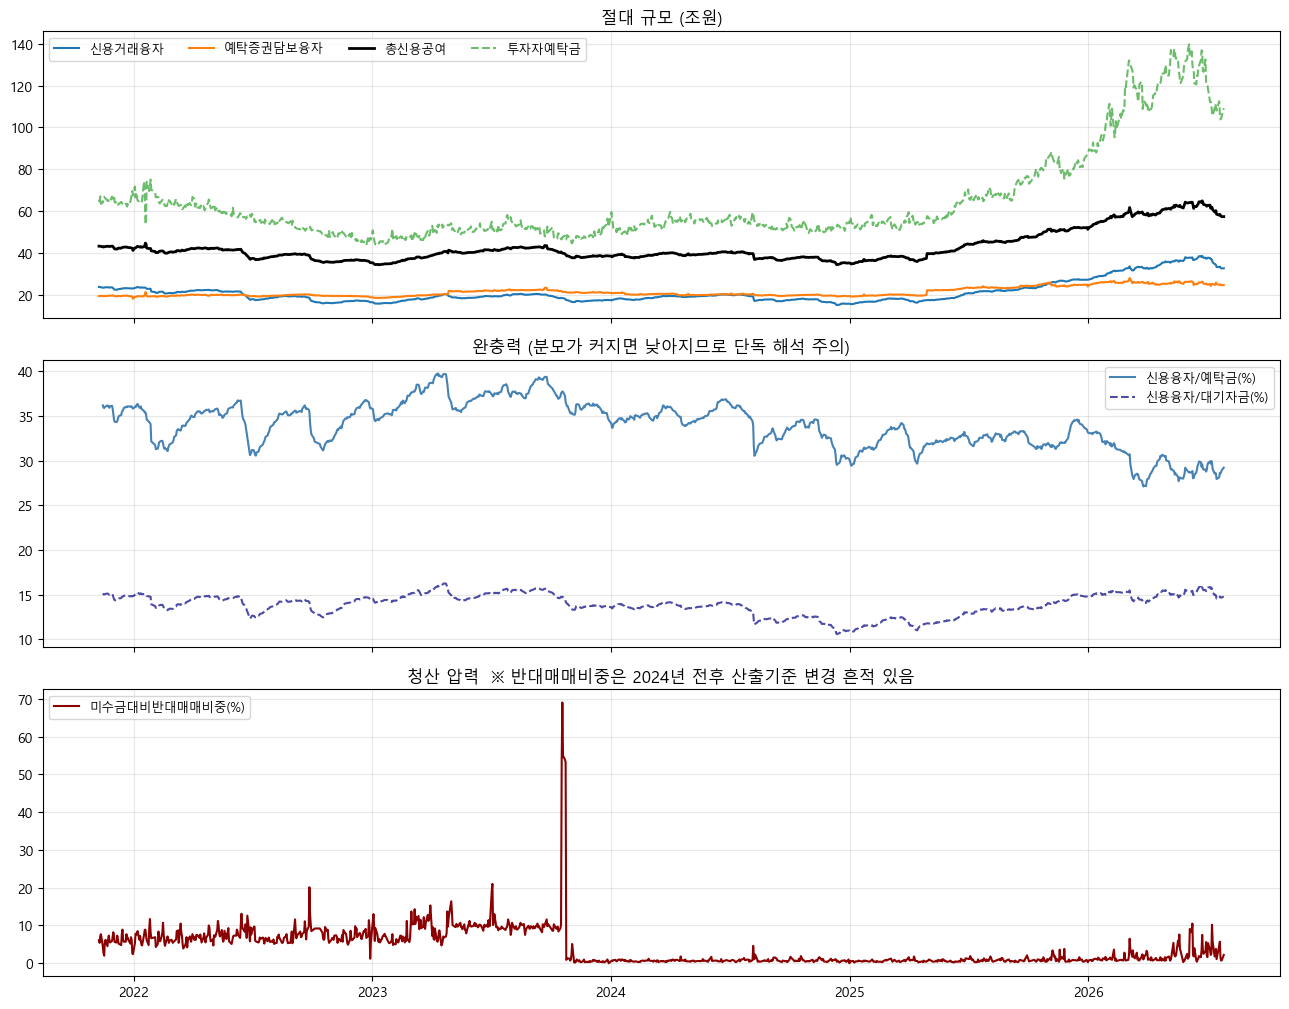

In [17]:
import matplotlib
import matplotlib.pyplot as plt

# 한글 폰트 자동 선택 (Windows/macOS/Linux 공통)
import platform
from matplotlib import font_manager


def set_korean_font():
    prefer = {
        "Windows": ["Malgun Gothic", "NanumGothic", "Gulim"],
        "Darwin":  ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic"],
        "Linux":   ["NanumGothic", "NanumBarunGothic", "Noto Sans CJK KR"],
    }
    have = {f.name for f in font_manager.fontManager.ttflist}
    for name in prefer.get(platform.system(), []) + ["Malgun Gothic", "AppleGothic"]:
        if name in have:
            matplotlib.rcParams["font.family"] = name
            return name
    print("!! 한글 폰트를 찾지 못했습니다. 라벨이 네모로 깨질 수 있습니다.")
    return None


print("차트 폰트:", set_korean_font())
matplotlib.rcParams["axes.unicode_minus"] = False

nrow = 4 if HAS_INDEX else 3
fig, ax = plt.subplots(nrow, 1, figsize=(13, 3.4 * nrow), sharex=True)

# (1) 절대 규모
ax[0].plot(ind["basDt"], ind["신용융자"], label="신용거래융자")
ax[0].plot(ind["basDt"], ind["담보융자"], label="예탁증권담보융자")
ax[0].plot(ind["basDt"], ind["총신용공여"], label="총신용공여", lw=2, color="k")
ax[0].plot(ind["basDt"], ind["예탁금"], label="투자자예탁금", ls="--", alpha=0.7)
ax[0].set_title("절대 규모 (조원)")
ax[0].legend(ncol=4, fontsize=9)
ax[0].grid(alpha=0.3)

# (2) 핵심 비율 — 신용/시총
if HAS_INDEX:
    ax[1].plot(ind["basDt"], ind["신용융자/시총(%)"], color="crimson",
               label="신용융자/시총(%)")
    ax[1].plot(ind["basDt"], ind["총신용공여/시총(%)"], color="darkred", ls="--",
               alpha=0.7, label="총신용공여/시총(%)")
    for q, st in [(0.5, ":"), (0.9, "-.")]:
        v = ind["신용융자/시총(%)"].quantile(q)
        ax[1].axhline(v, color="gray", ls=st, lw=0.9)
        ax[1].text(ind["basDt"].iloc[5], v, " p{:.0f}".format(q * 100),
                   fontsize=8, color="gray", va="bottom")
    ax[1].set_title("레버리지 / 시가총액 (%)  ← 핵심 지표")
    ax[1].legend(fontsize=9)
    ax[1].grid(alpha=0.3)
    k = 2
else:
    k = 1

# (3) 완충력
ax[k].plot(ind["basDt"], ind["신용융자/예탁금(%)"], color="steelblue",
           label="신용융자/예탁금(%)")
ax[k].plot(ind["basDt"], ind["신용융자/대기자금(%)"], color="navy", ls="--",
           alpha=0.7, label="신용융자/대기자금(%)")
ax[k].set_title("완충력 (분모가 커지면 낮아지므로 단독 해석 주의)")
ax[k].legend(fontsize=9)
ax[k].grid(alpha=0.3)

# (4) 청산 압력
ax[k + 1].plot(ind["basDt"], ind["미수금대비반대매매비중"], color="darkred",
               label="미수금대비반대매매비중(%)")
if HAS_INDEX:
    a2 = ax[k + 1].twinx()
    a2.plot(ind["basDt"], ind["청산일수"], color="navy", alpha=0.7, label="청산일수(일)")
    a2.set_ylabel("청산일수", color="navy")
    a2.legend(loc="upper right", fontsize=9)
ax[k + 1].set_title("청산 압력  ※ 반대매매비중은 2024년 전후 산출기준 변경 흔적 있음")
ax[k + 1].legend(loc="upper left", fontsize=9)
ax[k + 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 9-1. 4분면 — 같은 숫자라도 방향에 따라 의미가 다릅니다

신용잔고는 시가 재평가가 없고 시총은 매일 마킹됩니다. 그래서 `신용/시총` 이
오르는 이유가 두 가지로 갈립니다.

| | 시장 상승 중 | 시장 하락 중 |
|---|---|---|
| **비율 상승** | 신규 차입이 주가보다 빠름 → **버블형 축적** | 주가만 빠지고 빚은 안 줄어듦 → **청산 대기 물량** |
| **비율 하락** | 건전한 상승 | 반대매매로 정리 중 |

x축에 지수 60일 수익률, y축에 신용/시총 60일 변화를 놓고 최근 1년 궤적을 그립니다.

In [18]:
if "지수_60일수익률(%)" in ind.columns:
    q = ind.dropna(subset=["지수_60일수익률(%)", "신용시총비_60일변화(%p)"]).copy()
    recent = q.tail(250)

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.scatter(q["지수_60일수익률(%)"], q["신용시총비_60일변화(%p)"],
               s=8, c="lightgray", label="전체 기간")
    sc = ax.scatter(recent["지수_60일수익률(%)"], recent["신용시총비_60일변화(%p)"],
                    s=18, c=range(len(recent)), cmap="viridis", label="최근 1년")
    ax.scatter(q["지수_60일수익률(%)"].iloc[-1], q["신용시총비_60일변화(%p)"].iloc[-1],
               s=200, marker="*", c="red", zorder=5, label="현재")

    ax.axhline(0, color="k", lw=0.8)
    ax.axvline(0, color="k", lw=0.8)

    xmax = q["지수_60일수익률(%)"].abs().max() * 0.6
    ymax = q["신용시총비_60일변화(%p)"].abs().max() * 0.6
    ax.text(xmax, ymax, "버블형 축적", ha="center", color="crimson", fontsize=11)
    ax.text(-xmax, ymax, "청산 대기 물량", ha="center", color="darkorange", fontsize=11)
    ax.text(xmax, -ymax, "건전한 상승", ha="center", color="green", fontsize=11)
    ax.text(-xmax, -ymax, "디레버리징", ha="center", color="steelblue", fontsize=11)

    ax.set_xlabel("지수 60일 수익률 (%)")
    ax.set_ylabel("신용융자/시총 60일 변화 (%p)")
    ax.set_title("레버리지 축적 국면 4분면")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax, label="최근 1년 경과 (밝을수록 최근)")
    plt.tight_layout()
    plt.show()
else:
    print("지수 데이터가 없어 4분면을 건너뜁니다. (FETCH_INDEX 확인)")

지수 데이터가 없어 4분면을 건너뜁니다. (FETCH_INDEX 확인)


## 10. 저장

`<OUT_DIR>/증시자금동향_{날짜}.xlsx`

시트: `지표`, `현재진단`, `증시자금추이`, `신용공여잔고추이`, `지수시세`, `요약`

In [19]:
# -*- coding: utf-8 -*-
import os
from datetime import datetime


def make_date_tag():
    if DATE_TAG_MODE == "lastdata":
        cands = [df["basDt"].max() for df in (df_market, df_credit)
                 if len(df) and df["basDt"].notna().any()]
        if cands:
            return max(cands).strftime("%Y%m%d")
    return datetime.now().strftime("%Y%m%d")


def resolve_filename(out_dir, base_name, ext=".xlsx"):
    path = os.path.join(out_dir, base_name + ext)
    if OVERWRITE or not os.path.exists(path):
        return path
    i = 2
    while True:
        path = os.path.join(out_dir, "{}_v{}{}".format(base_name, i, ext))
        if not os.path.exists(path):
            return path
        i += 1


def safe_write_excel(path, sheets):
    """열려 있는 파일이면 타임스탬프 이름으로 우회 저장"""
    def _write(p):
        with pd.ExcelWriter(p, engine="openpyxl", datetime_format="yyyy-mm-dd") as w:
            for name, df in sheets:
                if df is not None and len(df):
                    df.to_excel(w, sheet_name=name, index=False)
    try:
        _write(path)
        return path
    except PermissionError:
        root, ext = os.path.splitext(path)
        alt = "{}_{}{}".format(root, datetime.now().strftime("%H%M%S"), ext)
        print("!! 파일이 열려 있어 다른 이름으로 저장합니다.")
        _write(alt)
        return alt


date_tag = make_date_tag()
base_name = "{}_{}".format(FILE_PREFIX, date_tag)

sheet_ind    = ind.rename(columns={"basDt": "기준일자"})
sheet_market = df_market.rename(columns=MARKET_KOR)
sheet_credit = df_credit.rename(columns=CREDIT_KOR)
sheet_index  = (df_index_agg.rename(columns={
                    "basDt": "기준일자", "mktcap_raw": "시가총액_원",
                    "turnover_raw": "거래대금_원"})
                if HAS_INDEX else None)

summary = pd.DataFrame([
    ["수집일시", datetime.now().strftime("%Y-%m-%d %H:%M:%S")],
    ["데이터 최종 기준일", date_tag],
    ["지표 행수", len(ind)],
    ["지표 기간", "{} ~ {}".format(ind["basDt"].min().date(), ind["basDt"].max().date())],
    ["증시자금추이 행수", len(df_market)],
    ["신용공여잔고추이 행수", len(df_credit)],
    ["지수시세 사용", "예" if HAS_INDEX else "아니오"],
    ["금액 단위", "조원 (지표 시트 기준)"],
    ["출처", "공공데이터포털 금융위원회 (금융투자협회종합통계정보 / 지수시세정보)"],
], columns=["항목", "값"])

xlsx_path = resolve_filename(OUT_DIR, base_name, ".xlsx")
saved = safe_write_excel(xlsx_path, [
    ("지표", sheet_ind),
    ("현재진단", diag),
    ("증시자금추이", sheet_market),
    ("신용공여잔고추이", sheet_credit),
    ("지수시세", sheet_index),
    ("요약", summary),
])

print("저장 완료 :", saved)

if SAVE_CSV_TOO:
    csv_dir = os.path.join(OUT_DIR, "csv")
    os.makedirs(csv_dir, exist_ok=True)
    for nm, df in [("지표", sheet_ind), ("증시자금추이", sheet_market),
                   ("신용공여잔고추이", sheet_credit)]:
        p = os.path.join(csv_dir, "{}_{}_{}.csv".format(FILE_PREFIX, nm, date_tag))
        df.to_csv(p, index=False, encoding="utf-8-sig")
        print("CSV 저장   :", p)

print("\n폴더 내 파일 목록:")
for f in sorted(os.listdir(OUT_DIR)):
    print("   ", f)

저장 완료 : C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\한국_증시자금동향\증시자금동향_20260727.xlsx
CSV 저장   : C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\한국_증시자금동향\csv\증시자금동향_지표_20260727.csv
CSV 저장   : C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\한국_증시자금동향\csv\증시자금동향_증시자금추이_20260727.csv
CSV 저장   : C:\Users\82108\OneDrive\INVESTMENT\지표상회_복제\한국_증시자금동향\csv\증시자금동향_신용공여잔고추이_20260727.csv

폴더 내 파일 목록:
    csv
    증시자금동향_20260727.xlsx


## 11. 데이터 점검 (선택)

In [20]:
for name, df in [("증시자금추이", df_market), ("신용공여잔고추이", df_credit),
                 ("지표", ind)]:
    print("=" * 55)
    print(name, "| rows:", len(df))
    print("  중복 기준일자:", int(df["basDt"].duplicated().sum()))
    na = df.isna().sum()
    na = na[na > 0]
    if len(na):
        print("  결측 상위:")
        for k, v in na.sort_values(ascending=False).head(8).items():
            print("     {:<32} {}".format(k, v))
    else:
        print("  결측: 없음")

증시자금추이 | rows: 1164
  중복 기준일자: 0
  결측: 없음
신용공여잔고추이 | rows: 1151
  중복 기준일자: 0
  결측: 없음
지표 | rows: 1154
  중복 기준일자: 0
  결측 상위:
     미수금대비반대매매비중_z                    735
     미수금대비반대매매비중_pct                  735
     신용융자_60일증가율(%)_pct               475
     신용융자/예탁금(%)_pct                  419
     신용융자/대기자금(%)_pct                 419
     신용융자_60일증가율(%)_z                 309
     신용융자/예탁금(%)_z                    253
     신용융자/대기자금(%)_z                   253


## 12. 트러블슈팅

### 지표·단위 관련

**신용 계열만 값이 이상하게 큼/작음**
- 단위 문제입니다. 신용공여는 백만원, 증시자금은 원입니다.
  `UNIT_DIVISOR` 를 확인하세요. 조원 기준이면 신용융자는 15~30 범위,
  예탁금은 40~80 범위로 나와야 정상입니다.

**`신용융자/시총(%)` 값이 비정상**
- 지수 API의 `lstgMrktTotAmt` 단위가 원이 아닐 수 있습니다.
  7번 셀의 단위 확인 출력에서 코스피+코스닥 시총이 2,000~3,000조 범위인지 보고
  `UNIT_DIVISOR['index']` 를 조정하세요.

**백분위가 전부 '표본부족'**
- `BEGIN_DT` 를 앞당기세요. 5년 백분위를 쓰려면 최소 2~3년치는 필요합니다.
- 또는 `PCT_WIN`, `Z_WIN` 을 줄이세요 (예: 500 / 250).

**`신용융자/예탁금` 이 특정일에 급락**
- 대형 공모주 청약일에 예탁금이 일시적으로 급증한 것입니다. 이미 20일 MA를
  적용해 완화했지만, 더 매끈하게 하려면 `MA_SHORT` 를 늘리세요.

### 지수시세정보 API

**`[20] SERVICE_ACCESS_DENIED_ERROR`**
- 지수시세정보는 **별도 활용신청**이 필요합니다. 승인 전이면
  `FETCH_INDEX = False` 로 두고 나머지 지표만 쓰세요.

**지수 데이터가 0건**
- `INDEX_NAMES` 의 표기가 실제와 다릅니다. 7번 진단 셀 출력에서 정확한
  문자열을 확인해 그대로 복사하세요.

### 저장 경로

**`[6] OneDrive 경로를 찾지 못해...`**
- `OUT_DIR_OVERRIDE` 에 실제 경로를 직접 넣으세요. 문자열 앞의 `r` 을 빼면
  `\U`, `\1` 등이 이스케이프로 해석되어 깨집니다.

**`[5] 폴더명으로 검색` 이 오래 걸림**
- 한 번 찾은 경로를 `OUT_DIR_OVERRIDE` 에 고정해 두면 이후로는 즉시 넘어갑니다.

**`PermissionError`**
- 같은 엑셀 파일을 열어둔 상태입니다. 자동으로 타임스탬프 파일이 생성됩니다.

### 인증·트래픽

**`[30] SERVICE_KEY_IS_NOT_REGISTERED_ERROR`**
- Encoding 키를 `params=`로 넘긴 경우가 대부분입니다. **Decoding 키**로 교체하세요.
- 신규 신청 키는 적용까지 최대 1~2시간 걸릴 수 있습니다.

**`[22] LIMITED_NUMBER_OF_SERVICE_REQUESTS_EXCEEDS_ERROR`**
- 개발계정 일 트래픽 초과. 2015년부터 3개 API를 받으면 호출 수가 꽤 됩니다.
  기간을 나눠서 받거나 다음 날 재시도하세요.

### 지표 해석 주의

이 지표들은 시장 전체의 레버리지 수준을 **측정**하는 도구입니다. 백분위가 높다고
곧 하락한다는 뜻이 아니고, 낮다고 안전하다는 뜻도 아닙니다. 특히 `신용/시총` 은
주가 하락만으로도 올라가므로 반드시 4분면과 함께 보세요.